# Walking Route Safety — Quantum-Inspired Notebook

This is the notebook version of the Hackathon route app. **Run the cells from top to bottom.** Change the settings in **Section 4** and rerun Sections 5–6 to try another journey. The notebook contains the scoring, classical comparison, and **quantum-inspired evolutionary algorithm (QIEA)** itself; it does not import `app.py`, `route_core.py`, or `quantum_inspired.py`.

It uses the saved `wits_walk_10km.graphml` file, so it **does not download OpenStreetMap data again**. QIEA runs on the CPU. No quantum computer or Qiskit installation is needed for this notebook.

## 1. Load the mapped walking network

The graph contains walkable street segments. Each segment may have OpenStreetMap tags for lighting, sidewalks, surface, and road class. The tags describe mapped infrastructure, **not the likelihood of GBV or crime**. Lighting and sidewalk data are sparse around Wits, so unknown must remain visible in every result.

In [1]:
from pathlib import Path
from collections import Counter
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

DATA_DIR = Path.cwd()
if not (DATA_DIR / "wits_walk_10km.graphml").exists():
    DATA_DIR = Path("/Users/courtneybrown/Library/Mobile Documents/com~apple~CloudDocs/PhD/Hackathon")
GRAPH_PATH = DATA_DIR / "wits_walk_10km.graphml"
assert GRAPH_PATH.exists(), f"Map file missing: {GRAPH_PATH}"
graph = ox.io.load_graphml(GRAPH_PATH)
print(f"Loaded {len(graph.nodes):,} nodes and {len(graph.edges):,} directed edges")

Loaded 155,198 nodes and 340,720 directed edges


## 2. Street scoring and classical route search

The scoring prototype starts with **1 point per 100 m** of walking, then adds **3** for explicitly unlit segments, **3** for explicitly absent sidewalks, **2** for major-road exposure, and **4** at crossings explicitly tagged unmarked. Unknown lighting and sidewalks receive smaller penalties and are reported separately. These weights are illustrative and should be calibrated with local input.

The classical baseline examines up to 100 score-ranked paths and keeps those meeting the chosen detour and continuous-unlit limits. Because this is a bounded candidate search, failure to find a route **does not prove that none exists**. The source code below was copied into the notebook so you can inspect and edit it here.

In [2]:
"""Starter routing logic for the Wits walking-route hackathon.

Scores describe mapped walking conditions, not the probability of crime or GBV.
Unknown lighting is kept separate from confirmed unlit streets.
"""

from __future__ import annotations

import ast
from itertools import islice
from math import cos, radians

import networkx as nx


def nearest_node(graph, latitude, longitude):
    """Find a nearby node without OSMnx's optional scikit-learn dependency."""
    lon_scale = cos(radians(latitude))
    return min(
        graph.nodes,
        key=lambda node: (
            (float(graph.nodes[node]["y"]) - latitude) ** 2
            + ((float(graph.nodes[node]["x"]) - longitude) * lon_scale) ** 2
        ),
    )


def _tag(value):
    """Normalise common OSMnx/GraphML tag shapes."""
    if value is None:
        return ""
    if isinstance(value, (list, tuple)):
        return str(value[0]).lower() if value else ""
    value = str(value)
    if value.startswith("["):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and parsed:
                return str(parsed[0]).lower()
        except (ValueError, SyntaxError):
            pass
    return value.lower()


def street_conditions(data):
    """Return three-valued lighting/sidewalk status and a traffic proxy."""
    lit = _tag(data.get("lit"))
    if lit in {"yes", "24/7", "automatic"}:
        lighting = "lit"
    elif lit in {"no", "disused"}:
        lighting = "unlit"
    else:
        lighting = "unknown"

    sidewalk = _tag(data.get("sidewalk"))
    sides = [_tag(data.get(f"sidewalk:{side}")) for side in ("left", "right")]
    if sidewalk in {"both", "yes", "left", "right", "separate"} or any(
        s in {"yes", "separate"} for s in sides
    ):
        pavement = "mapped"
    elif sidewalk in {"no", "none"} or sides == ["no", "no"]:
        pavement = "none"
    else:
        pavement = "unknown"

    road_type = _tag(data.get("highway"))
    # Road class is a rough proxy, not measured traffic volume.
    traffic_proxy = road_type in {"primary", "secondary", "tertiary", "trunk"}
    return lighting, pavement, traffic_proxy


def edge_score(data, *, weights=None):
    """Prototype score; lower is preferred. Unknowns are reported, not assumed safe."""
    w = weights or {
        "distance": 1.0, "unlit": 3.0, "unknown_lighting": 1.5,
        "no_sidewalk": 3.0, "unknown_sidewalk": 1.0, "traffic": 2.0,
    }
    length = float(data.get("length", 0.0))
    lighting, pavement, traffic = street_conditions(data)
    per_100m = (
        w["distance"]
        + w["unlit"] * (lighting == "unlit")
        + w["unknown_lighting"] * (lighting == "unknown")
        + w["no_sidewalk"] * (pavement == "none")
        + w["unknown_sidewalk"] * (pavement == "unknown")
        + w["traffic"] * traffic
    )
    return max(length, 0.0) / 100.0 * per_100m


def scored_digraph(graph):
    """Keep the lowest-scoring version of each directed street connection."""
    simple = nx.DiGraph()
    simple.add_nodes_from(graph.nodes(data=True))
    for u, v, _key, data in graph.edges(keys=True, data=True):
        candidate = dict(data)
        candidate["score"] = edge_score(candidate)
        # Only penalise a crossing explicitly mapped as unmarked/absent.
        if _tag(graph.nodes[v].get("crossing")) in {"unmarked", "no"}:
            candidate["score"] += 4.0
        candidate["length"] = float(candidate.get("length", 0.0))
        if not simple.has_edge(u, v) or candidate["score"] < simple[u][v]["score"]:
            simple.add_edge(u, v, **candidate)
    return simple


def route_profile(graph, route):
    """Calculate route score and longest consecutive confirmed-unlit stretch."""
    distance = score = unlit_run = longest_unlit = unknown_lighting = 0.0
    missing_sidewalk_m = 0.0
    for u, v in zip(route, route[1:]):
        data = graph[u][v]
        length = data["length"]
        lighting, pavement, _ = street_conditions(data)
        distance += length
        score += data["score"]
        if lighting == "unlit":
            unlit_run += length
            longest_unlit = max(longest_unlit, unlit_run)
        else:
            unlit_run = 0.0
        if lighting == "unknown":
            unknown_lighting += length
        if pavement == "none":
            missing_sidewalk_m += length
    return {
        "distance_m": round(distance, 1),
        "score": round(score, 2),
        "longest_unlit_m": round(longest_unlit, 1),
        "unknown_lighting_m": round(unknown_lighting, 1),
        "missing_sidewalk_m": round(missing_sidewalk_m, 1),
    }


def find_routes(
    graph,
    source,
    target,
    *,
    max_unlit_m=100.0,
    max_detour_pct=20.0,
    avoid_unknown_lighting=False,
    candidates_to_check=100,
    return_count=3,
):
    """Starter candidate search. An empty result is NOT proof no feasible route exists."""
    scored = scored_digraph(graph)
    shortest_m = nx.shortest_path_length(graph, source, target, weight="length")
    allowed_m = shortest_m * (1 + max_detour_pct / 100.0)
    feasible = []
    candidate_paths = nx.shortest_simple_paths(scored, source, target, weight="score")
    for route in islice(candidate_paths, candidates_to_check):
        profile = route_profile(scored, route)
        if profile["distance_m"] > allowed_m:
            continue
        if profile["longest_unlit_m"] > max_unlit_m:
            continue
        if avoid_unknown_lighting and profile["unknown_lighting_m"] > 0:
            continue
        feasible.append((route, profile))
        if len(feasible) >= return_count:
            break
    return feasible, {"shortest_m": round(shortest_m, 1), "allowed_m": round(allowed_m, 1), "checked_up_to": candidates_to_check}



In [3]:
lighting_counts = Counter()
sidewalk_counts = Counter()
for _, _, _, edge in graph.edges(keys=True, data=True):
    lighting, sidewalk, _ = street_conditions(edge)
    lighting_counts[lighting] += 1
    sidewalk_counts[sidewalk] += 1
print("Lighting status:", dict(lighting_counts))
print("Sidewalk status:", dict(sidewalk_counts))

Lighting status: {'unknown': 339804, 'lit': 890, 'unlit': 26}
Sidewalk status: {'unknown': 339304, 'mapped': 1392, 'none': 24}


## 3. Quantum-inspired evolutionary route search (QIEA)

QIEA searches a **small network of real mapped street chains**. Each chain is a binary include/exclude choice. The algorithm stores a probability amplitude for each choice, samples route combinations, checks connectivity and your hard limits, and rotates those probabilities toward the best valid route. It is a **classical algorithm inspired by qubit representation and rotation gates**; it does not create quantum circuits or use quantum hardware. The source below is included directly in this notebook.

### Does it follow the Qiskit pattern?

| Stage | This notebook | Actual Qiskit QAOA |
|---|---|---|
| **Map** | Convert the street graph into binary chain choices, costs, and user constraints. | Map a problem to a quantum Hamiltonian and circuit. |
| **Optimize** | Update QIEA sampling probabilities toward better valid routes. | Optimize a circuit and its parameters for quantum execution. |
| **Execute** | Sample candidates and evaluate them **on the CPU**. | Execute circuits using a simulator or quantum backend. |
| **Post-process** | Decode chosen chains into a route, validate constraints, compare, and plot. | Interpret measured bitstrings as classical results. |

So the **workflow structure is similar**, but QIEA's “execute” step is classical. It does **not** use Qiskit primitives or demonstrate quantum advantage. See [IBM's Qiskit pattern](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/utility-i) and a [QIEA study](https://doi.org/10.1016/j.cam.2015.02.016).

In [4]:
"""Quantum-inspired evolutionary search over a compact real-map route network.

This is a classical algorithm: a probability amplitude (angle) is maintained for
each binary macro-edge, candidate bitstrings are sampled, and the angles are
rotated toward the best valid route. It does not run on a quantum computer.
"""

from __future__ import annotations

from dataclasses import dataclass
from itertools import islice
from math import pi

import networkx as nx
import numpy as np



@dataclass
class Corridor:
    scored: nx.DiGraph
    source: int
    target: int
    edges: list[dict]
    seeds: list[tuple[int, ...]]
    shortest_m: float


def build_corridor(graph, source, target, *, max_edges=14, search_paths=100):
    """Compress a few distinct mapped paths into binary street-chain choices."""
    scored = scored_digraph(graph)
    shortest_m = nx.shortest_path_length(graph, source, target, weight="length")
    generator = nx.shortest_simple_paths(scored, source, target, weight="score")
    paths = []
    edge_sets = []
    for path in islice(generator, search_paths):
        selected = set(zip(path, path[1:]))
        if not edge_sets or all(len(selected & old) / len(selected | old) < 0.9 for old in edge_sets):
            paths.append(path)
            edge_sets.append(selected)
        if len(paths) == 3:
            break
    if not paths:
        raise nx.NetworkXNoPath("No walking route found")

    # Keep the largest path set that fits the small binary experiment.
    while paths:
        union = nx.DiGraph()
        for path in paths:
            union.add_edges_from(zip(path, path[1:]))
        junctions = {
            node for node in union
            if node in {source, target} or union.in_degree(node) != 1 or union.out_degree(node) != 1
        }
        chains = []
        elementary_to_chain = {}
        for start in junctions:
            for successor in union.successors(start):
                chain = [start, successor]
                while chain[-1] not in junctions:
                    chain.append(next(iter(union.successors(chain[-1]))))
                chain_id = len(chains)
                for pair in zip(chain, chain[1:]):
                    elementary_to_chain[pair] = chain_id
                chains.append({
                    "start": start,
                    "end": chain[-1],
                    "nodes": chain,
                    "score": sum(scored[u][v]["score"] for u, v in zip(chain, chain[1:])),
                })
        if len(chains) <= max_edges:
            seeds = []
            for path in paths:
                bits = [0] * len(chains)
                for pair in zip(path, path[1:]):
                    bits[elementary_to_chain[pair]] = 1
                seeds.append(tuple(bits))
            return Corridor(scored, source, target, chains, seeds, shortest_m)
        paths.pop()
        edge_sets.pop()
    raise ValueError("Could not build a compact corridor")


def decode_route(corridor, bits):
    """Expand a selected set of macro-edges; reject branches and disconnected loops."""
    selected = [i for i, bit in enumerate(bits) if bit]
    outgoing = {}
    for i in selected:
        start = corridor.edges[i]["start"]
        if start in outgoing:
            return None
        outgoing[start] = i
    route = [corridor.source]
    used = set()
    current = corridor.source
    while current != corridor.target:
        if current not in outgoing:
            return None
        edge_id = outgoing[current]
        if edge_id in used:
            return None
        used.add(edge_id)
        chain = corridor.edges[edge_id]["nodes"]
        route.extend(chain[1:])
        current = chain[-1]
        if len(route) > len(corridor.scored):
            return None
    if len(used) != len(selected) or len(route) != len(set(route)):
        return None
    return route


def assess(corridor, bits, *, max_unlit_m, max_detour_pct, avoid_unknown):
    route = decode_route(corridor, bits)
    if route is None:
        return None
    profile = route_profile(corridor.scored, route)
    allowed_m = corridor.shortest_m * (1 + max_detour_pct / 100)
    if profile["distance_m"] > allowed_m + 0.1:
        return None
    if profile["longest_unlit_m"] > max_unlit_m + 0.1:
        return None
    if avoid_unknown and profile["unknown_lighting_m"] > 0:
        return None
    return route, profile


def solve_qiea(
    corridor,
    *,
    max_unlit_m=100,
    max_detour_pct=20,
    avoid_unknown=False,
    generations=30,
    population=24,
    seed=7,
):
    """Binary QIEA: observe amplitudes, evaluate routes, rotate toward the elite."""
    rng = np.random.default_rng(seed)
    n = len(corridor.edges)
    theta = np.full(n, pi / 4)  # |alpha|^2 = |beta|^2 = 0.5
    best = None
    best_bits = None
    evaluated = 0

    for generation in range(generations):
        probabilities = np.sin(theta) ** 2
        samples = rng.random((population, n)) < probabilities
        # Preserve real mapped routes as valid starting chromosomes.
        for index, bits in enumerate(corridor.seeds[: min(len(corridor.seeds), population)]):
            samples[index] = bits
        if best_bits is not None and len(corridor.seeds) < population:
            samples[len(corridor.seeds)] = best_bits

        for sample in samples:
            evaluated += 1
            result = assess(
                corridor, sample,
                max_unlit_m=max_unlit_m,
                max_detour_pct=max_detour_pct,
                avoid_unknown=avoid_unknown,
            )
            if result is not None and (best is None or result[1]["score"] < best[1]["score"]):
                best = result
                best_bits = sample.copy()

        if best_bits is not None:
            # A classical analogue of a qubit rotation gate: move the angle
            # toward |1> for selected edges and toward |0> for omitted edges.
            rotation = 0.055 * (1 - generation / max(generations, 1))
            theta += np.where(best_bits, rotation, -rotation)
            theta = np.clip(theta, 0.08, pi / 2 - 0.08)

    return best, {"macro_edges": n, "seed_routes": len(corridor.seeds), "evaluations": evaluated}


## 4. Your journey and limits

Edit these values, then rerun **Sections 5–6**. Coordinates use `(latitude, longitude)`. The defaults go from Wits Main Campus toward West Campus. “Maximum unlit stretch” applies to **consecutive segments explicitly mapped unlit**. Unknown lighting is not counted as verified lit; enable `AVOID_UNKNOWN_LIGHTING` if every segment must have mapped lighting information.

In [5]:
START = (-26.1928, 28.0303)
END = (-26.189375, 28.024797)
MAX_CONTINUOUS_UNLIT_M = 100
MAX_EXTRA_DISTANCE_PCT = 20
AVOID_UNKNOWN_LIGHTING = False
QIEA_GENERATIONS = 30
QIEA_POPULATION = 24
QIEA_RANDOM_SEED = 7

## 5. Run both algorithms and compare

The classical baseline and QIEA use the same street scores and user limits. QIEA operates on a compressed corridor built from a few mapped route alternatives. A score tie or identical route is a valid comparison result; neither algorithm is guaranteed to find the global optimum here.

In [6]:
source = nearest_node(graph, *START)
target = nearest_node(graph, *END)
assert source != target, "Start and end snapped to the same map node. Choose points farther apart."

classical_routes, classical_stats = find_routes(
    graph, source, target,
    max_unlit_m=MAX_CONTINUOUS_UNLIT_M,
    max_detour_pct=MAX_EXTRA_DISTANCE_PCT,
    avoid_unknown_lighting=AVOID_UNKNOWN_LIGHTING,
    candidates_to_check=100,
    return_count=1,
)
classical_result = classical_routes[0] if classical_routes else None

corridor = build_corridor(graph, source, target)
qiea_result, qiea_stats = solve_qiea(
    corridor,
    max_unlit_m=MAX_CONTINUOUS_UNLIT_M,
    max_detour_pct=MAX_EXTRA_DISTANCE_PCT,
    avoid_unknown=AVOID_UNKNOWN_LIGHTING,
    generations=QIEA_GENERATIONS,
    population=QIEA_POPULATION,
    seed=QIEA_RANDOM_SEED,
)

rows = []
for method, result in (("Classical baseline", classical_result), ("Quantum-inspired QIEA", qiea_result)):
    if result:
        rows.append({"Method": method, **result[1]})
    else:
        rows.append({"Method": method, "Note": "No qualifying route among candidates searched"})
display(pd.DataFrame(rows))
print("QIEA search:", qiea_stats)
if any(result and result[1]["unknown_lighting_m"] > 0 for result in (classical_result, qiea_result)):
    print("IMPORTANT: Lighting is unknown on part of the route. Verify conditions locally.")

,Method,distance_m,score,longest_unlit_m,unknown_lighting_m,missing_sidewalk_m
0,Classical baseline,813.1,28.46,0.0,813.1,0.0
1,Quantum-inspired QIEA,813.1,28.46,0.0,813.1,0.0


QIEA search: {'macro_edges': 6, 'seed_routes': 3, 'evaluations': 720}
IMPORTANT: Lighting is unknown on part of the route. Verify conditions locally.


## 6. Show the routes on a local map

The grey lines are nearby mapped walking segments. **Blue** is the classical baseline and **magenta** is QIEA. If both algorithms choose the same route, the magenta line will cover the blue one. The plot uses only a small area around the result, so it is faster than drawing the entire 10 km graph.

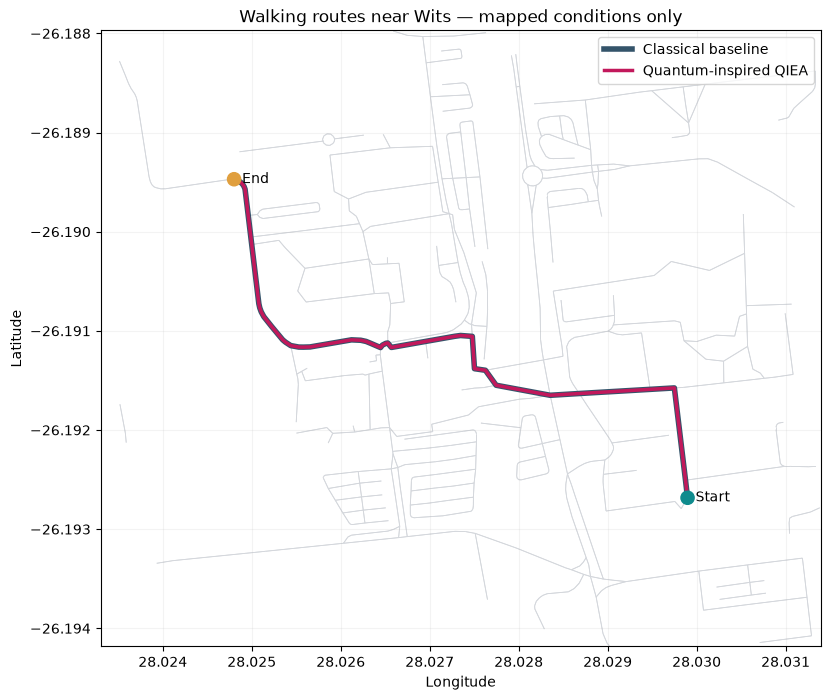

In [7]:
results = [("Classical baseline", classical_result, "#34546A", 4),
           ("Quantum-inspired QIEA", qiea_result, "#C2185B", 2.5)]
visible = [result for _, result, _, _ in results if result]
if not visible:
    print("No qualifying route to plot. Adjust the limits or increase the search range.")
else:
    route_nodes = {node for route, _ in visible for node in route}
    xs = [float(graph.nodes[node]["x"]) for node in route_nodes]
    ys = [float(graph.nodes[node]["y"]) for node in route_nodes]
    pad = 0.0015
    west, east = min(xs) - pad, max(xs) + pad
    south, north = min(ys) - pad, max(ys) + pad
    background = []
    for u, v in graph.edges():
        a, b = graph.nodes[u], graph.nodes[v]
        if west <= float(a["x"]) <= east and south <= float(a["y"]) <= north and west <= float(b["x"]) <= east and south <= float(b["y"]) <= north:
            background.append([(float(a["x"]), float(a["y"])), (float(b["x"]), float(b["y"]))])
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.add_collection(LineCollection(background, colors="#d4d7dc", linewidths=0.6, zorder=1))
    for label, result, color, width in results:
        if result:
            route = result[0]
            ax.plot([float(graph.nodes[n]["x"]) for n in route],
                    [float(graph.nodes[n]["y"]) for n in route],
                    color=color, linewidth=width, label=label, zorder=3)
    ax.scatter([float(graph.nodes[source]["x"]), float(graph.nodes[target]["x"])],
               [float(graph.nodes[source]["y"]), float(graph.nodes[target]["y"])],
               c=["#0f8b8d", "#e09f3e"], s=90, zorder=5)
    ax.text(float(graph.nodes[source]["x"]), float(graph.nodes[source]["y"]), "  Start", va="center")
    ax.text(float(graph.nodes[target]["x"]), float(graph.nodes[target]["y"]), "  End", va="center")
    ax.set_xlim(west, east); ax.set_ylim(south, north)
    ax.set_aspect(1 / np.cos(np.deg2rad((south + north) / 2)))
    ax.set_title("Walking routes near Wits — mapped conditions only")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(); ax.grid(alpha=0.15)
    plt.show()

## What is complete and what comes next

**Complete:** use the saved Wits walking network; score mapped street conditions; let a user change route limits; run a classical baseline and a **CPU-based QIEA** on real route alternatives; compare and plot their results.

**Data limits:** Most local OSM edges have no lighting or sidewalk tags. “0 m mapped unlit” can therefore coexist with substantial **unknown lighting**. Road class is only a proxy for traffic. A field survey or trustworthy local data source is needed before calling a route well lit or suitable for safety-critical navigation.

**Algorithm limits:** QIEA explores a bounded compact corridor. The classical baseline checks a bounded set of paths. This notebook is a hackathon prototype, not a proof of quantum speedup or a production navigation service. The earlier `extract_wits.ipynb` has a **separate QAOA toy example** if you want to compare an actual quantum-circuit approach later.